In [1]:
# =============================================================================
# Leuven Carrier-Receiver Collaboration Analysis
# =============================================================================
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gzip
from lxml import etree
import matsim
from shapely.geometry import Point, LineString

# Configuration and Paths

In [2]:
# Base output path for Leuven Carrier-Receiver Collaboration
leuven_output_path = r'output/leuvenCarrierReceiverCollab60Receivers/'

# Network path
network_path = r'data/GemeenteLeuvenWithHbefaType/GemeenteLeuvenWithHbefaType.xml.gz'

# Folder naming pattern: leuvenCRCollab-{depot_location}-{distribution}-{method}-af{af}-p{penalty}-i{instance}
# depot_location: 'inside' or 'outside' (the study area)
# distribution: 'clustered' or 'dispersed'
# method: 'approx_shapley_mc', 'approx_shapley_stratified', 'marginal', 'proportional'
# af: allocation factor (e.g., 0.80)
# penalty: penalty value (e.g., 0.0000)
# instance: instance number (e.g., i01)

# Get all folders
all_leuven_folders = [f for f in os.listdir(leuven_output_path) if os.path.isdir(os.path.join(leuven_output_path, f))]
print(f"Total folders: {len(all_leuven_folders)}")
print(f"Sample folders: {all_leuven_folders[:5]}")

Total folders: 144
Sample folders: ['leuvenCRCollab-outside-clustered-proportional-af0.80-p0.0140-i01', 'leuvenCRCollab-inside-clustered-approx_shapley_stratified-af0.80-p0.0140-i01', 'leuvenCRCollab-inside-clustered-marginal-af0.80-p0.0003-i01', 'leuvenCRCollab-inside-clustered-approx_shapley_mc-af0.80-p0.0280-i01', 'leuvenCRCollab-inside-clustered-approx_shapley_stratified-af0.80-p0.0008-i01']


In [3]:
global_methodsAndColors = { #'exactShapley': '#ff7f0e',
              'marginal': '#1f77b4', 
              'proportional': '#2ca02c', 
              'approx_shapley_mc': '#d62728', 
              'approx_shapley_stratified': '#9467bd'}

# Read Network using matsim package

In [4]:
# Read network using matsim package - returns a GeoDataFrame with links as LineStrings
network = matsim.read_network(network_path)
network_gdf = network.as_geo()

print(f"Network contains {len(network_gdf)} links")
network_gdf.head()

Network contains 103753 links


,length,freespeed,capacity,permlanes,oneway,modes,link_id,from_node,to_node,geometry
0,7.221720,13.888889,1277.777778,2.0,1,bike,100006229_1-1085376891_0,453075429,453075431,"LINESTRING (175094.462 171579.032, 175087.718 ..."
1,7.924752,13.888889,1277.777778,2.0,1,bike,100006230_1-1085376884_0,1472593946,1156261854,"LINESTRING (175094.956 171547.998, 175102.682 ..."
2,8.518773,13.888889,1277.777778,2.0,1,bike,100006231_0-1085376890_0,1156261856,453075428,"LINESTRING (175114.241 171571.774, 175106.042 ..."
3,50.128561,33.333333,2666.666667,3.5,1,"bike,car",100010104_0,1156293852,1156293879,"LINESTRING (174065.63 177001.873, 174056.23 17..."
4,14.524426,33.333333,2666.666667,3.5,1,"bike,car",100010104_1,1156293879,1156293875,"LINESTRING (174056.23 177051.111, 174070.62 17..."


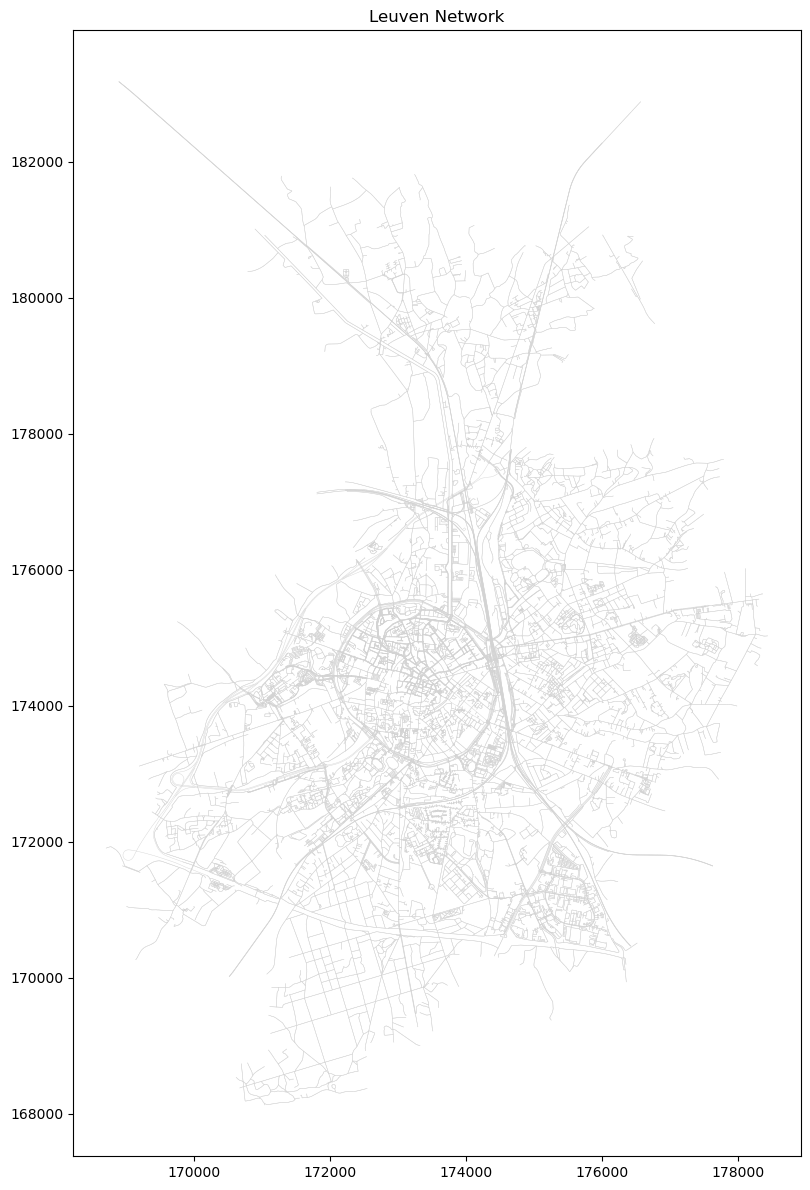

In [5]:
# Visualize the network
fig, ax = plt.subplots(figsize=(12, 12))
network_gdf.plot(ax=ax, color='lightgrey', linewidth=0.3)
ax.set_title('Leuven Network')
plt.tight_layout()
plt.show()

# Core Functions: Parse Folder Name and Read XML Files

In [6]:
# =============================================================================
# Core Parsing Functions
# =============================================================================

def parse_leuven_folder_name(folder_name):
    """
    Parse the Leuven folder naming pattern.
    Pattern: leuvenCRCollab-{depot_location}-{distribution}-{method}-af{af}-p{penalty}-i{instance}
    
    Example: leuvenCRCollab-inside-clustered-approx_shapley_mc-af0.80-p0.0000-i01
    
    Returns:
    --------
    dict : Dictionary with keys 'depot_location', 'distribution', 'method', 'af', 'penalty', 'instance'
    """
    parts = folder_name.split('-')
    
    # Extract components based on position
    depot_location = parts[1]  # 'inside' or 'outside'
    distribution = parts[2]     # 'clustered' or 'dispersed'
    
    # Method can have underscores, need to find where af starts
    af_idx = None
    for i, part in enumerate(parts):
        if part.startswith('af'):
            af_idx = i
            break
    
    method = '-'.join(parts[3:af_idx]) if af_idx else parts[3]
    af = parts[af_idx].replace('af', '') if af_idx else None
    penalty = parts[af_idx + 1].replace('p', '') if af_idx else None
    instance = parts[af_idx + 2] if af_idx else None
    
    return {
        'depot_location': depot_location,
        'distribution': distribution,
        'method': method,
        'af': af,
        'penalty': penalty,
        'instance': instance
    }


def read_receivers_from_xml(receiver_file_path):
    """
    Read receiver information from receivers.xml.gz file.
    
    Returns:
    --------
    DataFrame with columns: receiver_id, link_id, affiliated_carrier_id, 
                           collaboration_status, grand_coalition_member, score,
                           selected_plan_score, time_window_start, time_window_end, order_carrier_id
    """
    receivers_data = []
    
    with gzip.open(receiver_file_path, 'rb') as f:
        tree = etree.parse(f)
        root = tree.getroot()
    
    for receiver in root.findall('.//receiver'):
        receiver_id = receiver.get('id')
        link_id = receiver.get('linkId')
        
        # Parse attributes
        attributes = {}
        for attr in receiver.findall('.//attribute'):
            attr_name = attr.get('name')
            attr_value = attr.text
            # Convert to appropriate type
            attr_class = attr.get('class', '')
            if 'Boolean' in attr_class:
                attr_value = attr_value.lower() == 'true'
            elif 'Double' in attr_class:
                attr_value = float(attr_value)
            attributes[attr_name] = attr_value
        
        # Get selected plan info
        selected_plan = receiver.find(".//plan[@selected='yes']")
        selected_plan_score = None
        time_window_start = None
        time_window_end = None
        order_carrier_id = None
        
        if selected_plan is not None:
            selected_plan_score = float(selected_plan.get('score', -100))
            time_window = selected_plan.find('timeWindow')
            if time_window is not None:
                time_window_start = time_window.get('start')
                time_window_end = time_window.get('end')
            order = selected_plan.find('order')
            if order is not None:
                order_carrier_id = order.get('carrierId')
        
        receivers_data.append({
            'receiver_id': receiver_id,
            'link_id': link_id,
            'affiliated_carrier_id': attributes.get('affiliatedCarrierId'),
            'collaboration_status': attributes.get('collaborationStatus', False),
            'grand_coalition_member': attributes.get('grandCoalitionMember', False),
            'score': attributes.get('score', -100),
            'selected_plan_score': selected_plan_score,
            'time_window_start': time_window_start,
            'time_window_end': time_window_end,
            'order_carrier_id': order_carrier_id
        })
    receivers_data_df = pd.DataFrame(receivers_data)
    # Convert the time-related columns (like "06:00:00") to datetime 
    receivers_data_df['time_window_start'] = pd.to_datetime(receivers_data_df['time_window_start'], format='%H:%M:%S').dt.time
    receivers_data_df['time_window_end'] = pd.to_datetime(receivers_data_df['time_window_end'], format='%H:%M:%S').dt.time

    return receivers_data_df

def read_carriers_from_xml(carrier_file_path):
    """
    Read carrier information from carriers.xml.gz file.
    
    Returns:
    --------
    DataFrame with columns: carrier_id, depot_link_id, vehicle_ids, jsprit_score, num_shipments
    """
    carriers_data = []
    
    with gzip.open(carrier_file_path, 'rb') as f:
        tree = etree.parse(f)
        root = tree.getroot()
    
    # Handle namespace
    ns = {'m': 'http://www.matsim.org/files/dtd'}
    
    for carrier in root.findall('.//{http://www.matsim.org/files/dtd}carrier'):
        carrier_id = carrier.get('id')
        
        # Get depot link IDs from vehicles
        depot_links = set()
        vehicle_ids = []
        for vehicle in carrier.findall('.//{http://www.matsim.org/files/dtd}vehicle'):
            depot_link_id = vehicle.get('depotLinkId')
            vehicle_id = vehicle.get('id')
            if depot_link_id:
                depot_links.add(depot_link_id)
            if vehicle_id:
                vehicle_ids.append(vehicle_id)
        
        # Count shipments
        shipments = carrier.findall('.//{http://www.matsim.org/files/dtd}shipment')
        num_shipments = len(shipments)
        
        # Get jsprit score from selected plan
        jsprit_score = None
        selected_plan = carrier.find('.//{http://www.matsim.org/files/dtd}plan[@selected="true"]')
        if selected_plan is not None:
            for attr in selected_plan.findall('.//{http://www.matsim.org/files/dtd}attribute'):
                if attr.get('name') == 'jspritScore':
                    jsprit_score = float(attr.text)
        
        # Get score from selected plan
        carrier_score = None
        if selected_plan is not None:
            carrier_score = float(selected_plan.get('score'))

        carriers_data.append({
            'carrier_id': carrier_id,
            'depot_link_ids': list(depot_links),
            'depot_link_id': list(depot_links)[0] if depot_links else None,  # Primary depot
            'vehicle_ids': vehicle_ids,
            'num_vehicles': len(vehicle_ids),
            'jsprit_score': jsprit_score,
            'carrier_score': carrier_score,
            'num_shipments': num_shipments
        })
    
    return pd.DataFrame(carriers_data)


def read_receiver_stats_csv(stats_file_path):
    """
    Read receiver_stats.csv file which contains iteration-level receiver data.
    
    Returns:
    --------
    DataFrame with all receiver stats
    """
    return pd.read_csv(stats_file_path)



In [7]:

# Test the parsing function
sample_folder = all_leuven_folders[82]
print(f"Sample folder: {sample_folder}")
print(f"Parsed: {parse_leuven_folder_name(sample_folder)}")

Sample folder: leuvenCRCollab-outside-dispersed-approx_shapley_mc-af0.80-p0.0000-i01
Parsed: {'depot_location': 'outside', 'distribution': 'dispersed', 'method': 'approx_shapley_mc', 'af': '0.80', 'penalty': '0.0000', 'instance': 'i01'}


# Functions: Create GeoDataFrames for Receivers and Carriers

In [8]:
# =============================================================================
# GeoDataFrame Creation Functions
# =============================================================================

def get_link_centroid(link_id, network_gdf):
    """
    Get the centroid of a link from the network GeoDataFrame.
    
    Parameters:
    -----------
    link_id : str
        The link ID
    network_gdf : GeoDataFrame
        Network GeoDataFrame from matsim.read_network().as_geo()
    
    Returns:
    --------
    Point : Shapely Point at the centroid of the link, or None if not found
    """
    gdf = network_gdf.query('link_id == @link_id ')
    if not gdf.empty:
        return gdf.iloc[0].geometry.centroid
    return None


def create_receiver_gdf(receiver_df, network_gdf):
    """
    Create a GeoDataFrame of receivers with Point geometry based on link centroids.
    
    Parameters:
    -----------
    receiver_df : DataFrame
        DataFrame from read_receivers_from_xml()
    network_gdf : GeoDataFrame
        Network GeoDataFrame
    
    Returns:
    --------
    GeoDataFrame with receiver information and Point geometry
    """
    geometries = []
    for _, row in receiver_df.iterrows():
        geom = get_link_centroid(row['link_id'], network_gdf)
        geometries.append(geom)
    
    receiver_gdf = gpd.GeoDataFrame(receiver_df, geometry=geometries, crs=network_gdf.crs)
    # Remove rows with no geometry
    receiver_gdf = receiver_gdf[receiver_gdf.geometry.notna()]
    return receiver_gdf


def create_carrier_gdf(carrier_df, network_gdf):
    """
    Create a GeoDataFrame of carriers (depot locations) with Point geometry.
    
    Parameters:
    -----------
    carrier_df : DataFrame
        DataFrame from read_carriers_from_xml()
    network_gdf : GeoDataFrame
        Network GeoDataFrame
    
    Returns:
    --------
    GeoDataFrame with carrier information and Point geometry (depot location)
    """
    geometries = []
    for _, row in carrier_df.iterrows():
        geom = get_link_centroid(row['depot_link_id'], network_gdf)
        geometries.append(geom)
    
    carrier_gdf = gpd.GeoDataFrame(carrier_df, geometry=geometries, crs=network_gdf.crs)
    carrier_gdf = carrier_gdf[carrier_gdf.geometry.notna()]
    return carrier_gdf

def rectify_collaboration_status(receiver_df, tw=(6,8)):
    """
    Rectify collaboration status based on selected plan time window.
    if the selected plan's time window does not match the input original tw,
    label it collaboration_status=True. 

    Parameters:
    -----------
    receiver_df : DataFrame
        DataFrame of receivers
    tw : tuple
        Expected time window (start, end)
    
    Returns:
    --------
    DataFrame with updated collaboration_status
    """
    
    def check_tw(row):
        if row['time_window_start'] is None or row['time_window_end'] is None:
            raise ValueError(f"Receiver {row['receiver_id']} has no selected plan time window.")
        start = row['time_window_start'].hour
        end = row['time_window_end'].hour
        if start != tw[0] or end != tw[1]:
            return True
        else:
            return False
    
    receiver_df['collaboration_status'] = receiver_df.apply(check_tw, axis=1)
    return receiver_df


def load_scenario_data(output_path, folder_name, network_gdf, tw=(6,8)):
    """
    Load all data for a single scenario folder and return GeoDataFrames.
    
    Parameters:
    -----------
    output_path : str
        Base output path
    folder_name : str
        Folder name
    network_gdf : GeoDataFrame
        Network GeoDataFrame
    
    Returns:
    --------
    dict : Dictionary containing:
        - 'scenario_info': parsed folder name info
        - 'receiver_df': raw receiver DataFrame
        - 'receiver_gdf': receiver GeoDataFrame
        - 'carrier_df': raw carrier DataFrame
        - 'carrier_gdf': carrier GeoDataFrame
        - 'receiver_stats': receiver stats from CSV
    """
    folder_path = os.path.join(output_path, folder_name)
    
    # Parse folder name
    scenario_info = parse_leuven_folder_name(folder_name)
    
    # Read receivers
    receiver_file = os.path.join(folder_path, 'receivers.xml.gz')
    receiver_df = read_receivers_from_xml(receiver_file)
    receiver_df = rectify_collaboration_status(receiver_df, tw=tw)
    receiver_gdf = create_receiver_gdf(receiver_df, network_gdf)
    
    # Read carriers
    carrier_file = os.path.join(folder_path, 'output_carriers.xml.gz')
    carrier_df = read_carriers_from_xml(carrier_file)
    carrier_gdf = create_carrier_gdf(carrier_df, network_gdf)
    
    # Read receiver stats
    stats_file = os.path.join(folder_path, 'receiver_stats.csv')
    receiver_stats = read_receiver_stats_csv(stats_file) if os.path.exists(stats_file) else None
    
    return {
        'scenario_info': scenario_info,
        'folder_name': folder_name,
        'receiver_df': receiver_df,
        'receiver_gdf': receiver_gdf,
        'carrier_df': carrier_df,
        'carrier_gdf': carrier_gdf,
        'receiver_stats': receiver_stats
    }

In [9]:

# Test loading a single scenario
sample_data = load_scenario_data(leuven_output_path, sample_folder, network_gdf)
print(f"Loaded scenario: {sample_data['scenario_info']}")
print(f"Receivers: {len(sample_data['receiver_df'])}")
print(f"Carriers: {len(sample_data['carrier_df'])}")

Loaded scenario: {'depot_location': 'outside', 'distribution': 'dispersed', 'method': 'approx_shapley_mc', 'af': '0.80', 'penalty': '0.0000', 'instance': 'i01'}
Receivers: 60
Carriers: 4


In [10]:
# Display sample receiver GeoDataFrame
sample_data['receiver_df']

,receiver_id,link_id,affiliated_carrier_id,collaboration_status,grand_coalition_member,score,selected_plan_score,time_window_start,time_window_end,order_carrier_id
0,receiver_10155487_r_11,10155487_r_11,None,True,True,-100.000000,-100.000000,06:00:00,10:00:00,carrier_27566523_11
1,receiver_1059368207_r_1,1059368207_r_1,None,True,True,146.676145,146.676145,06:00:00,11:00:00,carrier_333784188_r_3
2,receiver_114869077_r_1,114869077_r_1,None,True,True,-100.000000,-100.000000,06:00:00,09:00:00,carrier_27566523_11
3,receiver_11989384_0,11989384_0,None,True,True,509.421888,509.421888,06:00:00,09:00:00,carrier_131757263_1-131757263_2
4,receiver_1235806081_r_6-1235806081_r_7-1235806...,1235806081_r_6-1235806081_r_7-1235806081_r_8,None,True,True,-100.000000,-100.000000,06:00:00,09:00:00,carrier_333784188_r_3
5,receiver_125835552_r_2,125835552_r_2,None,False,True,-100.000000,-100.000000,06:00:00,08:00:00,carrier_333784188_r_3
6,receiver_125835582_5,125835582_5,None,True,True,-100.000000,-99.902232,06:00:00,09:00:00,carrier_25806807_r_1
7,receiver_126348346_2,126348346_2,None,False,True,-100.000000,-100.000000,06:00:00,08:00:00,carrier_333784188_r_3
8,receiver_12891213_0,12891213_0,None,True,True,-100.000000,-100.000000,06:00:00,09:00:00,carrier_27566523_11
9,receiver_129129415_r_1-129129415_r_2,129129415_r_1-129129415_r_2,None,True,True,-100.000000,-100.000000,06:00:00,09:00:00,carrier_333784188_r_3


In [11]:
# Display sample carrier GeoDataFrame
sample_data['carrier_df']

,carrier_id,depot_link_ids,depot_link_id,vehicle_ids,num_vehicles,jsprit_score,carrier_score,num_shipments
0,carrier_131757263_1-131757263_2,[131757263_1-131757263_2],131757263_1-131757263_2,"[lightVan_carrier_131757263_1-131757263_2, hea...",2,-594.553903,1280.876816,15
1,carrier_25806807_r_1,[25806807_r_1],25806807_r_1,"[lightVan_carrier_25806807_r_1, heavyVan_carri...",2,-931.830569,972.722220,15
2,carrier_27566523_11,[27566523_11],27566523_11,"[lightVan_carrier_27566523_11, heavyVan_carrie...",2,-932.283001,958.379698,15
3,carrier_333784188_r_3,[333784188_r_3],333784188_r_3,"[lightVan_carrier_333784188_r_3, heavyVan_carr...",2,-927.626344,906.091962,15


# Visualization Functions

In [12]:
# =============================================================================
# Visualization Functions
# =============================================================================

def plot_scenario_map(
    scenario_data,
    network_gdf,
    bbox=None,
    figsize=(12, 12),
    show_collaboration=True,
    title=None,
    show_carrier_assignment=False,
    emphasize_collab=False,
):
    """
    Plot a map showing network, receivers, and carriers for a scenario.

    Parameters
    ----------
    scenario_data : dict
        Output from load_scenario_data()
    network_gdf : GeoDataFrame
        Network GeoDataFrame
    bbox : tuple, optional
        Bounding box (xmin, xmax, ymin, ymax) to crop the view
    figsize : tuple
        Figure size
    show_collaboration : bool
        If True, color receivers by collaboration status (ignored when show_carrier_assignment=True)
    title : str, optional
        Custom title
    show_carrier_assignment : bool, default False
        If True, color receivers by the carrier responsible (column `order_carrier_id`) and
        color carrier depots with the same palette.
    emphasize_collab : bool, default False
        If True, add a highlight ring to receivers with collaboration_status == True
    """
    receiver_gdf = scenario_data['receiver_gdf']
    carrier_gdf = scenario_data['carrier_gdf']
    info = scenario_data['scenario_info']

    fig, ax = plt.subplots(figsize=figsize)

    # Crop network if bbox provided
    if bbox:
        network_plot = network_gdf.cx[bbox[0]:bbox[1], bbox[2]:bbox[3]]
        receiver_plot = receiver_gdf.cx[bbox[0]:bbox[1], bbox[2]:bbox[3]]
        carrier_plot = carrier_gdf.cx[bbox[0]:bbox[1], bbox[2]:bbox[3]]
    else:
        network_plot = network_gdf
        receiver_plot = receiver_gdf
        carrier_plot = carrier_gdf

    # Plot network
    network_plot.plot(ax=ax, color='lightgrey', linewidth=0.3, alpha=0.8)

    # Receiver plotting helpers
    collab_highlight_added = False
    carrier_color_map = {}

    if show_carrier_assignment and 'order_carrier_id' in receiver_plot.columns:
        # Color by carrier assignment
        carriers = sorted(receiver_plot['order_carrier_id'].dropna().unique())
        cmap = plt.cm.get_cmap('tab20', max(len(carriers), 3))

        # Assign palette to carriers
        for idx, cid in enumerate(carriers):
            carrier_color_map[cid] = cmap(idx % cmap.N)

        # Handle unassigned (NaN) separately
        unassigned = receiver_plot[receiver_plot['order_carrier_id'].isna()]
        for idx, cid in enumerate(carriers):
            sub = receiver_plot[receiver_plot['order_carrier_id'] == cid]
            color = carrier_color_map[cid]
            ax.scatter(
                sub.geometry.x, sub.geometry.y,
                color=color, s=36, marker='o', edgecolors='black', linewidths=0.35,
                alpha=0.85, zorder=3,
                label=f"Carrier {cid} ({len(sub)})"
            )
            if emphasize_collab and 'collaboration_status' in sub.columns:
                collab_sub = sub[sub['collaboration_status'] == True]
                if len(collab_sub) > 0:
                    ax.scatter(
                        collab_sub.geometry.x, collab_sub.geometry.y,
                        facecolors='none', edgecolors='gold', linewidths=1.4,
                        s=64, marker='o', zorder=4,
                        label='Collaborative (highlight)' if not collab_highlight_added else None
                    )
                    collab_highlight_added = True
        if len(unassigned) > 0:
            ax.scatter(
                unassigned.geometry.x, unassigned.geometry.y,
                color='gray', s=36, marker='o', edgecolors='black', linewidths=0.35,
                alpha=0.7, zorder=3,
                label=f"Unassigned ({len(unassigned)})"
            )
            if emphasize_collab and 'collaboration_status' in unassigned.columns:
                collab_sub = unassigned[unassigned['collaboration_status'] == True]
                if len(collab_sub) > 0:
                    ax.scatter(
                        collab_sub.geometry.x, collab_sub.geometry.y,
                        facecolors='none', edgecolors='gold', linewidths=1.4,
                        s=64, marker='o', zorder=4,
                        label='Collaborative (highlight)' if not collab_highlight_added else None
                    )
                    collab_highlight_added = True
    else:
        # Original logic: color by collaboration status or default
        if show_collaboration and 'collaboration_status' in receiver_plot.columns:
            collab_receivers = receiver_plot[receiver_plot['collaboration_status'] == True]
            non_collab_receivers = receiver_plot[receiver_plot['collaboration_status'] == False]

            if len(non_collab_receivers) > 0:
                ax.scatter(
                    non_collab_receivers.geometry.x, non_collab_receivers.geometry.y,
                    color='red', s=36, marker='x', linewidths=1.2,
                    label=f"Non-collaborative ({len(non_collab_receivers)})", zorder=3
                )
            if len(collab_receivers) > 0:
                ax.scatter(
                    collab_receivers.geometry.x, collab_receivers.geometry.y,
                    color='blue', s=36, marker='o', alpha=0.75,
                    edgecolors='black', linewidths=0.3,
                    label=f"Collaborative ({len(collab_receivers)})", zorder=3
                )
                if emphasize_collab:
                    ax.scatter(
                        collab_receivers.geometry.x, collab_receivers.geometry.y,
                        facecolors='none', edgecolors='gold', linewidths=1.4,
                        s=64, marker='o', zorder=4,
                        label='Collaborative (highlight)'
                    )
        else:
            ax.scatter(
                receiver_plot.geometry.x, receiver_plot.geometry.y,
                color='blue', s=36, marker='o', alpha=0.75,
                edgecolors='black', linewidths=0.3,
                label=f"Receivers ({len(receiver_plot)})", zorder=3
            )
            if emphasize_collab and 'collaboration_status' in receiver_plot.columns:
                collab_receivers = receiver_plot[receiver_plot['collaboration_status'] == True]
                if len(collab_receivers) > 0:
                    ax.scatter(
                        collab_receivers.geometry.x, collab_receivers.geometry.y,
                        facecolors='none', edgecolors='gold', linewidths=1.4,
                        s=64, marker='o', zorder=4,
                        label='Collaborative (highlight)'
                    )

    # Plot carriers (depots)
    if show_carrier_assignment and carrier_color_map and 'carrier_id' in carrier_plot.columns:
        # Map carrier depot color by carrier_id if in map, else gray
        colors = []
        for _, row in carrier_plot.iterrows():
            cid = row.get('carrier_id')
            colors.append(carrier_color_map.get(cid, 'red'))
        ax.scatter(
            carrier_plot.geometry.x, carrier_plot.geometry.y,
            color=colors, s=180, marker='*', edgecolors='darkred', linewidths=1.2,
            label=f"Carrier Depots ({len(carrier_plot)})", zorder=5
        )
    else:
        ax.scatter(
            carrier_plot.geometry.x, carrier_plot.geometry.y,
            color='red', s=180, marker='*', edgecolors='darkred', linewidths=1.2,
            label=f"Carrier Depots ({len(carrier_plot)})", zorder=5
        )

    if title is None:
        title = (
            f"Leuven CR Collaboration\n"
            f"{info['depot_location'].title()} | {info['distribution'].title()} | {info['method']}\n"
            f"penalty={info['penalty']}"
        )

    ax.set_title(title, fontsize=12)
    ax.legend(loc='upper right', fontsize=9)
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')

    plt.tight_layout()
    plt.show()


def plot_receiver_scores_on_map(scenario_data, network_gdf, bbox=None, figsize=(12, 12)):
    """
    Plot receivers colored by their score.
    """
    receiver_gdf = scenario_data['receiver_gdf']
    carrier_gdf = scenario_data['carrier_gdf']
    info = scenario_data['scenario_info']

    fig, ax = plt.subplots(figsize=figsize)

    if bbox:
        network_plot = network_gdf.cx[bbox[0]:bbox[1], bbox[2]:bbox[3]]
        receiver_plot = receiver_gdf.cx[bbox[0]:bbox[1], bbox[2]:bbox[3]]
        carrier_plot = carrier_gdf.cx[bbox[0]:bbox[1], bbox[2]:bbox[3]]
    else:
        network_plot = network_gdf
        receiver_plot = receiver_gdf
        carrier_plot = carrier_gdf

    # Plot network
    network_plot.plot(ax=ax, color='lightgrey', linewidth=0.3, alpha=0.5)

    # Plot receivers colored by score
    # Filter out -100 scores (these are initialization scores)
    receiver_plot_valid = receiver_plot[receiver_plot['score'] > -100]

    if len(receiver_plot_valid) > 0:
        receiver_plot_valid.plot(
            ax=ax, column='score', cmap='RdYlGn', markersize=40,
            legend=True, legend_kwds={'label': 'Receiver Score'},
            alpha=0.8, zorder=3
        )

    # Plot carriers
    carrier_plot.plot(
        ax=ax, color='red', markersize=150, marker='*',
        label='Carrier Depots', zorder=4, edgecolor='darkred'
    )

    title = f"Receiver Scores\n{info['depot_location'].title()} | {info['distribution'].title()} | p={info['penalty']}"
    ax.set_title(title, fontsize=12)
    ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()


def compare_distributions(output_path, depot_location='inside', penalty='0.0000',
                          method='approx_shapley_mc', network_gdf=None, bbox=None,
                          figsize=(16, 7)):
    """
    Compare clustered vs dispersed distributions side by side.
    """
    all_folders = os.listdir(output_path)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    for idx, distribution in enumerate(['clustered', 'dispersed']):
        ax = axes[idx]

        # Find matching folder
        pattern = f'leuvenCRCollab-{depot_location}-{distribution}-{method}-af0.80-p{penalty}'
        matching = [f for f in all_folders if f.startswith(pattern)]

        if not matching:
            ax.text(0.5, 0.5, f'No data for {distribution}', ha='center', va='center')
            continue

        folder = matching[0]
        data = load_scenario_data(output_path, folder, network_gdf)

        receiver_gdf = data['receiver_gdf']
        carrier_gdf = data['carrier_gdf']

        if bbox:
            network_plot = network_gdf.cx[bbox[0]:bbox[1], bbox[2]:bbox[3]]
            receiver_plot = receiver_gdf.cx[bbox[0]:bbox[1], bbox[2]:bbox[3]]
            carrier_plot = carrier_gdf.cx[bbox[0]:bbox[1], bbox[2]:bbox[3]]
        else:
            network_plot = network_gdf
            receiver_plot = receiver_gdf
            carrier_plot = carrier_gdf

        # Plot
        network_plot.plot(ax=ax, color='lightgrey', linewidth=0.3, alpha=0.5)

        collab = receiver_plot[receiver_plot['collaboration_status'] == True]
        non_collab = receiver_plot[receiver_plot['collaboration_status'] == False]

        if len(non_collab) > 0:
            non_collab.plot(ax=ax, color='red', markersize=25, marker='x', zorder=3,
                           label=f'Non-collab ({len(non_collab)})')
        if len(collab) > 0:
            collab.plot(ax=ax, color='blue', markersize=25, marker='o', alpha=0.7, zorder=3,
                       label=f'Collab ({len(collab)})')

        carrier_plot.plot(ax=ax, color='red', markersize=120, marker='*', zorder=4,
                         edgecolor='darkred', label='Depot')

        ax.set_title(f"{distribution.title()} Distribution", fontsize=12)
        ax.legend(loc='upper right', fontsize=9)
        ax.set_xlabel('X (m)')
        ax.set_ylabel('Y (m)')

    fig.suptitle('Clustered vs Dispersed Distributions', fontsize=14)
    plt.tight_layout()
    plt.show()


# Example Visualizations

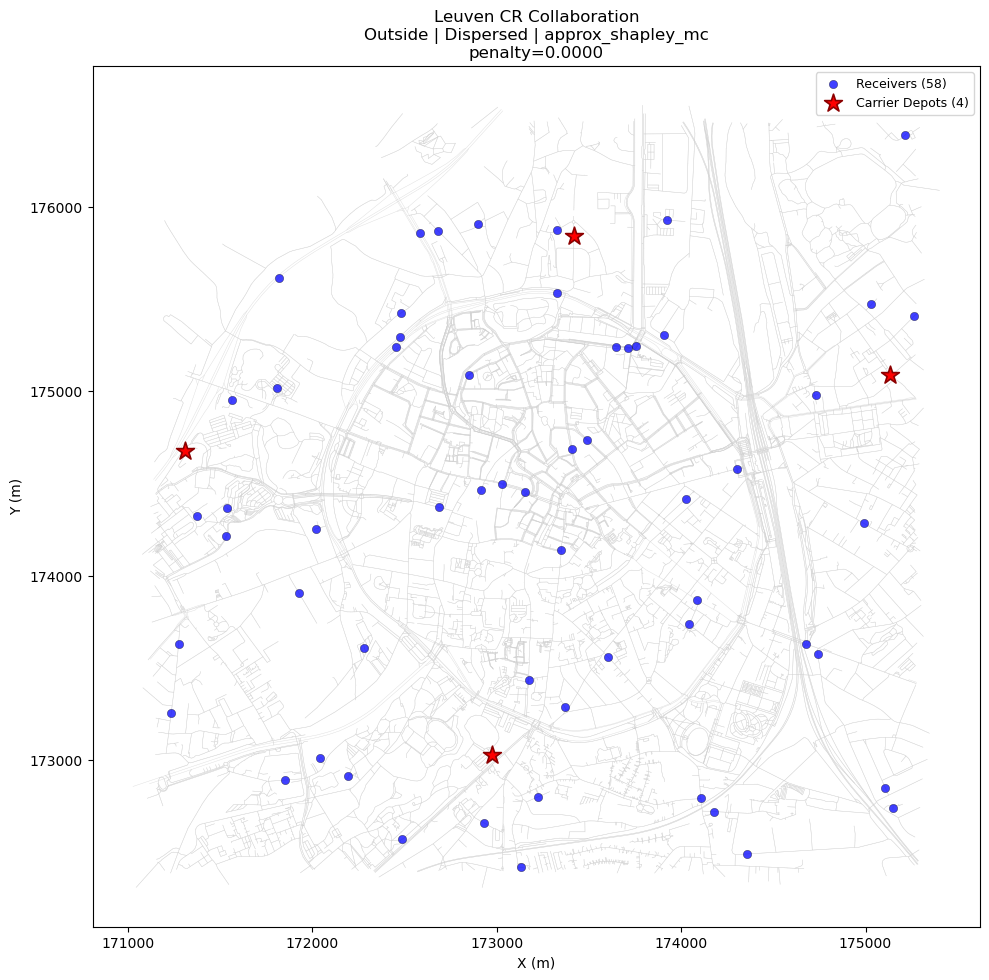

In [13]:
# Define bounding box for the study area (based on leuven_poi.ipynb)
# Visualization bbox: (Xmin:171161.734, Xmax:175265.856, Ymin:172412.828, Ymax:176444.093)
bbox_vis = (171161.734, 175265.856, 172412.828, 176444.093)
# Customer area bbox: (172161.734, 174265.856, 173412.828, 175444.093)
bbox_customer = (172161.734, 174265.856, 173412.828, 175444.093)

# Visualize sample scenario
plot_scenario_map(sample_data, network_gdf, 
                  show_collaboration=False,
                #   show_carrier_assignment=True,
                #   emphasize_collab=True,
                  bbox=bbox_vis, figsize=(10, 10))

In [ ]:
# Compare clustered vs dispersed distributions for inside depot
compare_distributions(leuven_output_path, depot_location='inside', penalty='0.0000', 
                      method='approx_shapley_mc', network_gdf=network_gdf, bbox=bbox_vis)

# Aggregate Analysis Functions

In [14]:
# =============================================================================
# Aggregate Analysis Functions
# =============================================================================

def collect_all_scenarios_summary(output_path, network_gdf):
    """
    Collect summary statistics for all scenarios.
    
    Returns:
    --------
    DataFrame with scenario info and summary statistics
    """
    all_folders = [f for f in os.listdir(output_path) if os.path.isdir(os.path.join(output_path, f))]
    
    summaries = []
    for folder in all_folders:
        try:
            folder_path = os.path.join(output_path, folder)
            info = parse_leuven_folder_name(folder)
            
            # Read receivers
            receiver_file = os.path.join(folder_path, 'receivers.xml.gz')
            receiver_df = read_receivers_from_xml(receiver_file)
            ## rectify the collaboration status
            rectify_collaboration_status(receiver_df)
            
            # Read carriers
            carrier_file = os.path.join(folder_path, 'output_carriers.xml.gz')
            carrier_df = read_carriers_from_xml(carrier_file)
            
            # Calculate summary stats
            total_receivers = len(receiver_df)
            collab_receivers = receiver_df['collaboration_status'].sum()
            non_collab_receivers = total_receivers - collab_receivers
            collab_rate = collab_receivers / total_receivers if total_receivers > 0 else 0
            
            # Score statistics (exclude -100 initial scores)
            valid_scores = receiver_df[receiver_df['score'] > -100]['score']
            mean_score = valid_scores.mean() if len(valid_scores) > 0 else np.nan
            min_score = valid_scores.min() if len(valid_scores) > 0 else np.nan
            max_score = valid_scores.max() if len(valid_scores) > 0 else np.nan
            total_receiver_scores = receiver_df['score'].sum()
            
            # Carrier stats
            total_carriers = len(carrier_df)
            total_shipments = carrier_df['num_shipments'].sum()
            total_jsprit_cost = carrier_df['jsprit_score'].sum()
            total_carrier_score = carrier_df['carrier_score'].sum()
            
            summaries.append({
                'folder': folder,
                'depot_location': info['depot_location'],
                'distribution': info['distribution'],
                'method': info['method'],
                'af': float(info['af']) if info['af'] else np.nan,
                'penalty': float(info['penalty']) if info['penalty'] else np.nan,
                'instance': info['instance'],
                'total_receivers': total_receivers,
                'collab_receivers': collab_receivers,
                'non_collab_receivers': non_collab_receivers,
                'collab_rate': collab_rate,
                'total_receiver_scores': total_receiver_scores, 
                'mean_receiver_score': mean_score,
                'min_receiver_score': min_score,
                'max_receiver_score': max_score,
                'total_carriers': total_carriers,
                'total_shipments': total_shipments,
                'total_jsprit_cost': total_jsprit_cost,
                'total_carrier_score': total_carrier_score
            })
            
        except Exception as e:
            print(f"Error processing {folder}: {e}")
            summaries.append({
                'folder': folder,
                'depot_location': info['depot_location'],
                'distribution': info['distribution'],
                'method': info['method'],
                'af': float(info['af']) if info['af'] else np.nan,
                'penalty': float(info['penalty']) if info['penalty'] else np.nan,
                'instance': info['instance'],
                'total_receivers': None,
                'collab_receivers': 0,
                'non_collab_receivers': None,
                'collab_rate': 0,
                'mean_receiver_score': None,
                'min_receiver_score': None,
                'max_receiver_score': None,
                'total_carriers': None,
                'total_shipments': None,
                'total_jsprit_cost': None,
                'total_carrier_score': None
            })
            continue
    
    return pd.DataFrame(summaries)


def count_collaborative_receivers_by_carrier(receiver_df):
    """
    Count how many receivers are collaborative for each affiliated carrier.
    """
    return receiver_df.groupby('affiliated_carrier_id').agg({
        'receiver_id': 'count',
        'collaboration_status': 'sum',
        'score': lambda x: x[x > -100].mean()
    }).rename(columns={
        'receiver_id': 'total_receivers',
        'collaboration_status': 'collab_receivers',
        'score': 'mean_score'
    }).reset_index()


def analyze_collaboration_by_penalty(summary_df):
    """
    Analyze how collaboration rate changes with penalty value.
    """
    return summary_df.groupby(['depot_location', 'distribution', 'method', 'penalty']).agg({
        'collab_rate': 'mean',
        'mean_receiver_score': 'mean',
        'total_jsprit_cost': 'mean'
    }).reset_index()


print("Aggregate analysis functions defined.")

Aggregate analysis functions defined.


In [15]:
# Collect summary for all scenarios (this may take a few minutes)
print("Collecting all scenario summaries...")
leuven_summary_df = collect_all_scenarios_summary(leuven_output_path, network_gdf)
print(f"Collected {len(leuven_summary_df)} scenarios")
leuven_summary_df.head(10)

Error processing leuvenCRCollab-outside-clustered-proportional-af0.80-p0.0140-i01: [Errno 2] No such file or directory: 'output/leuvenCarrierReceiverCollab60Receivers/leuvenCRCollab-outside-clustered-proportional-af0.80-p0.0140-i01/receivers.xml.gz'
Error processing leuvenCRCollab-inside-clustered-approx_shapley_stratified-af0.80-p0.0140-i01: [Errno 2] No such file or directory: 'output/leuvenCarrierReceiverCollab60Receivers/leuvenCRCollab-inside-clustered-approx_shapley_stratified-af0.80-p0.0140-i01/receivers.xml.gz'
Error processing leuvenCRCollab-inside-clustered-approx_shapley_mc-af0.80-p0.0280-i01: [Errno 2] No such file or directory: 'output/leuvenCarrierReceiverCollab60Receivers/leuvenCRCollab-inside-clustered-approx_shapley_mc-af0.80-p0.0280-i01/receivers.xml.gz'
Error processing leuvenCRCollab-inside-clustered-approx_shapley_stratified-af0.80-p0.0008-i01: [Errno 2] No such file or directory: 'output/leuvenCarrierReceiverCollab60Receivers/leuvenCRCollab-inside-clustered-approx_

,folder,depot_location,distribution,method,af,penalty,instance,total_receivers,collab_receivers,non_collab_receivers,collab_rate,mean_receiver_score,min_receiver_score,max_receiver_score,total_carriers,total_shipments,total_jsprit_cost,total_carrier_score,total_receiver_scores
0,leuvenCRCollab-outside-clustered-proportional-...,outside,clustered,proportional,0.8,0.0140,i01,NaN,0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,leuvenCRCollab-inside-clustered-approx_shapley...,inside,clustered,approx_shapley_stratified,0.8,0.0140,i01,NaN,0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,leuvenCRCollab-inside-clustered-marginal-af0.8...,inside,clustered,marginal,0.8,0.0003,i01,60.0,1,59.0,0.016667,-99.776767,-99.776767,-99.776767,4.0,60.0,-3561.998880,2763.897405,-5999.776767
3,leuvenCRCollab-inside-clustered-approx_shapley...,inside,clustered,approx_shapley_mc,0.8,0.0280,i01,NaN,0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,leuvenCRCollab-inside-clustered-approx_shapley...,inside,clustered,approx_shapley_stratified,0.8,0.0008,i01,NaN,0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,leuvenCRCollab-outside-clustered-proportional-...,outside,clustered,proportional,0.8,0.0008,i01,60.0,30,30.0,0.500000,-72.639474,-96.431288,-48.831219,4.0,60.0,-3241.598875,3281.225371,-5179.184207
6,leuvenCRCollab-inside-dispersed-proportional-a...,inside,dispersed,proportional,0.8,0.0008,i01,60.0,60,0.0,1.000000,-15.992953,-24.575992,-11.524841,4.0,60.0,-3735.615023,3849.882769,-959.577181
7,leuvenCRCollab-outside-dispersed-approx_shaple...,outside,dispersed,approx_shapley_mc,0.8,0.0056,i01,60.0,15,45.0,0.250000,183.108603,-67.335714,438.684914,4.0,60.0,-3740.007552,3451.606541,-2475.254308
8,leuvenCRCollab-inside-dispersed-proportional-a...,inside,dispersed,proportional,0.8,0.0140,i01,60.0,60,0.0,1.000000,-63.665294,-70.889421,-60.288269,4.0,60.0,-3739.389457,3869.098627,-3866.940643
9,leuvenCRCollab-inside-clustered-approx_shapley...,inside,clustered,approx_shapley_mc,0.8,0.0056,i01,NaN,0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
leuven_summary_df

,folder,depot_location,distribution,method,af,penalty,instance,total_receivers,collab_receivers,non_collab_receivers,collab_rate,mean_receiver_score,min_receiver_score,max_receiver_score,total_carriers,total_shipments,total_jsprit_cost,total_carrier_score,total_receiver_scores
0,leuvenCRCollab-outside-clustered-proportional-...,outside,clustered,proportional,0.8,0.0140,i01,NaN,0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,leuvenCRCollab-inside-clustered-approx_shapley...,inside,clustered,approx_shapley_stratified,0.8,0.0140,i01,NaN,0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,leuvenCRCollab-inside-clustered-marginal-af0.8...,inside,clustered,marginal,0.8,0.0003,i01,60.0,1,59.0,0.016667,-99.776767,-99.776767,-99.776767,4.0,60.0,-3561.998880,2763.897405,-5999.776767
3,leuvenCRCollab-inside-clustered-approx_shapley...,inside,clustered,approx_shapley_mc,0.8,0.0280,i01,NaN,0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,leuvenCRCollab-inside-clustered-approx_shapley...,inside,clustered,approx_shapley_stratified,0.8,0.0008,i01,NaN,0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,leuvenCRCollab-inside-clustered-approx_shapley...,inside,clustered,approx_shapley_mc,0.8,0.0098,i01,NaN,0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
140,leuvenCRCollab-outside-dispersed-approx_shaple...,outside,dispersed,approx_shapley_mc,0.8,0.0098,i01,60.0,13,47.0,0.216667,271.685709,51.976660,891.771328,4.0,60.0,-3736.354029,3703.857442,-2056.457254
141,leuvenCRCollab-outside-dispersed-marginal-af0....,outside,dispersed,marginal,0.8,0.0280,i01,60.0,7,53.0,0.116667,639.881129,-19.518087,907.475425,4.0,60.0,-3735.059419,3668.370334,-3668.498257
142,leuvenCRCollab-outside-clustered-approx_shaple...,outside,clustered,approx_shapley_stratified,0.8,0.0008,i01,NaN,0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
# Check unique values
print("Depot locations:", leuven_summary_df['depot_location'].unique())
print("Distributions:", leuven_summary_df['distribution'].unique())
print("Methods:", leuven_summary_df['method'].unique())
print("Penalties:", sorted(leuven_summary_df['penalty'].unique()))

Depot locations: ['outside' 'inside']
Distributions: ['clustered' 'dispersed']
Methods: ['proportional' 'approx_shapley_stratified' 'marginal' 'approx_shapley_mc']
Penalties: [np.float64(0.0), np.float64(0.0003), np.float64(0.0008), np.float64(0.0014), np.float64(0.0028), np.float64(0.0056), np.float64(0.0098), np.float64(0.014), np.float64(0.028)]


# Collaboration Rate Analysis Plots

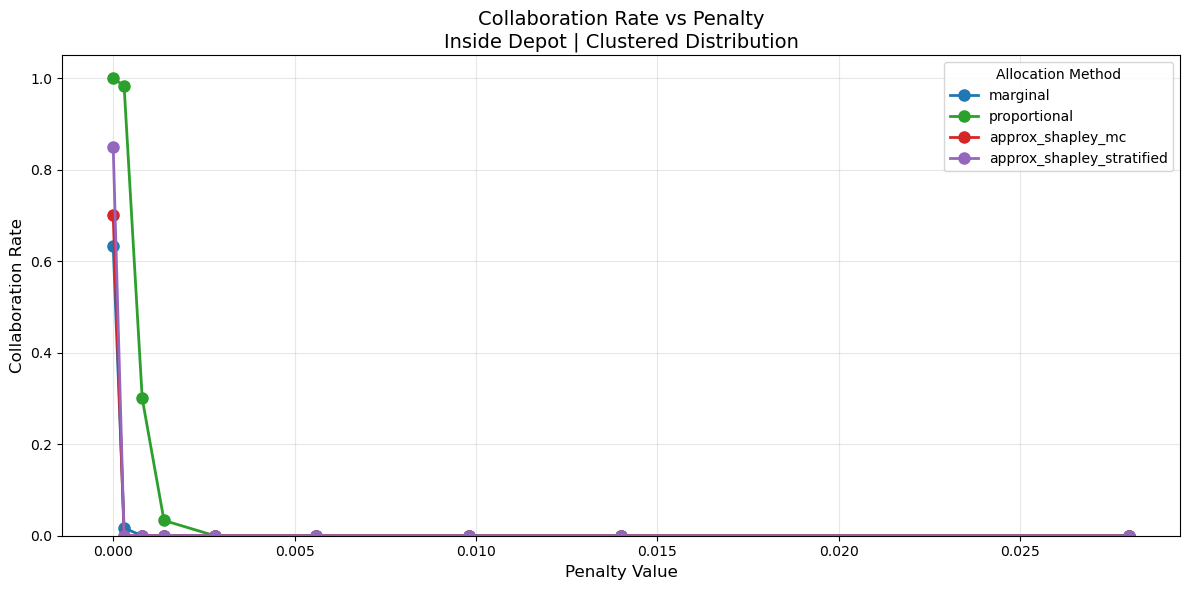

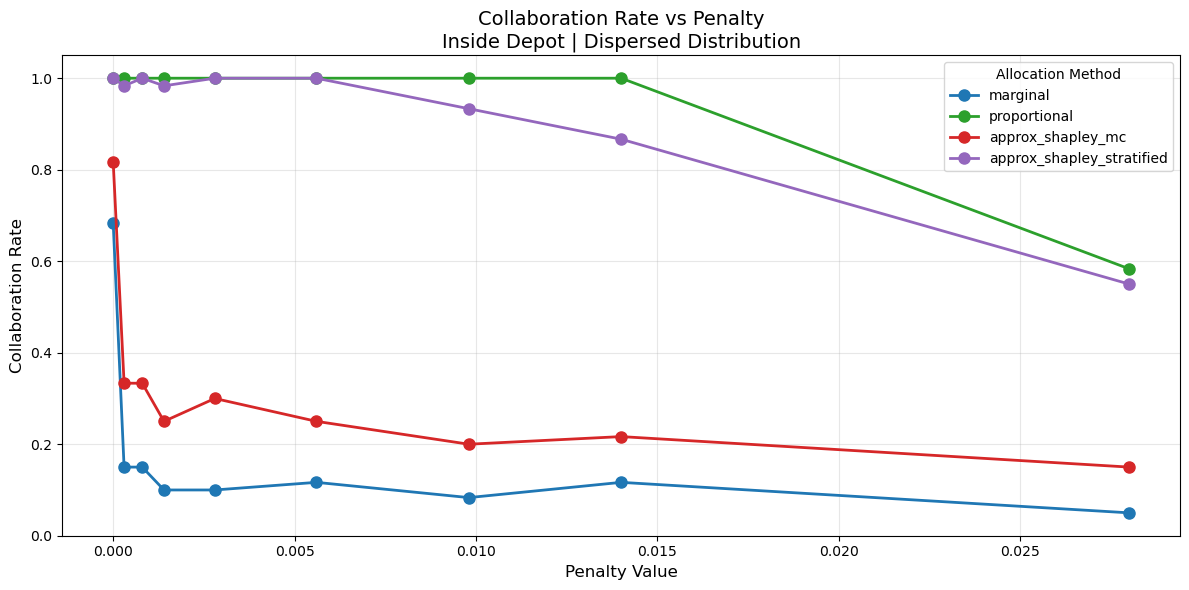

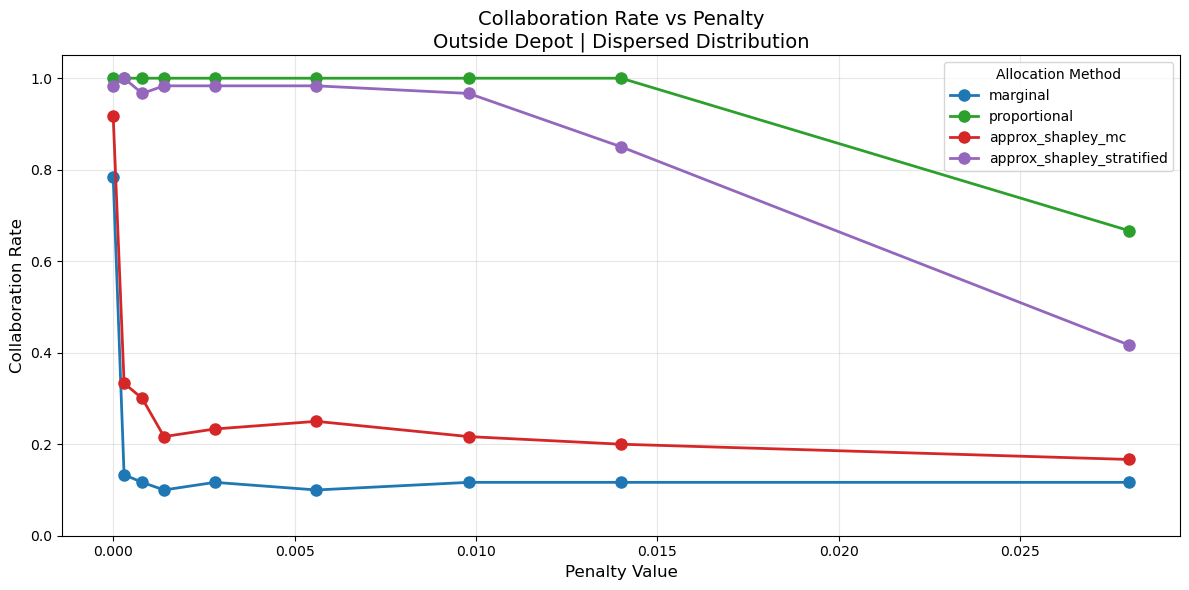

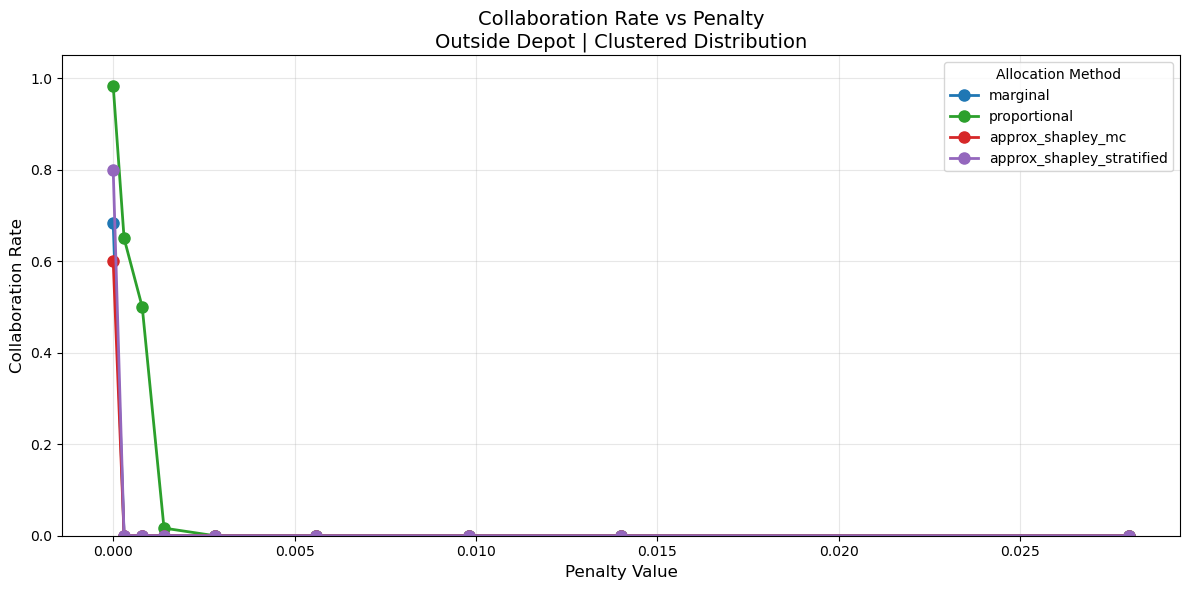

In [18]:
# Plot collaboration rate vs penalty for different methods
def plot_collab_rate_vs_penalty(summary_df, depot_location='inside', distribution='clustered', 
                                 figsize=(12, 6)):
    """
    Plot collaboration rate vs penalty for different allocation methods.
    """
    subset = summary_df[(summary_df['depot_location'] == depot_location) & 
                        (summary_df['distribution'] == distribution)]
    
    fig, ax = plt.subplots(figsize=figsize)
    
    methods = subset['method'].unique()
    colors = { #'exactShapley': '#ff7f0e',
              'marginal': '#1f77b4', 
              'proportional': '#2ca02c', 
              'approx_shapley_mc': '#d62728', 
              'approx_shapley_stratified': '#9467bd'}
    
    for method, color in colors.items():
        method_data = subset[subset['method'] == method].sort_values('penalty')
        ax.plot(method_data['penalty'], method_data['collab_rate'], 
                marker='o', label=method, color=color, linewidth=2, markersize=8)
    
    ax.set_xlabel('Penalty Value', fontsize=12)
    ax.set_ylabel('Collaboration Rate', fontsize=12)
    ax.set_title(f'Collaboration Rate vs Penalty\n{depot_location.title()} Depot | {distribution.title()} Distribution', 
                 fontsize=14)
    ax.legend(title='Allocation Method', loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.05)
    
    plt.tight_layout()
    plt.show()

# Plot for inside depot, clustered distribution
plot_collab_rate_vs_penalty(leuven_summary_df, depot_location='inside', distribution='clustered')
# Plot for inside depot, dispersed distribution
plot_collab_rate_vs_penalty(leuven_summary_df, depot_location='inside', distribution='dispersed')
# Plot for outside depot, dispersed distribution
plot_collab_rate_vs_penalty(leuven_summary_df, depot_location='outside', distribution='dispersed')
# Plot for outside depot, clustered distribution
plot_collab_rate_vs_penalty(leuven_summary_df, depot_location='outside', distribution='clustered')


In [19]:
# Compare clustered vs dispersed distributions
def plot_clustered_vs_dispersed(summary_df, depot_location='inside', method='approx_shapley_mc', 
                                 figsize=(10, 6)):
    """
    Plot collaboration rate for clustered vs dispersed distributions.
    """
    subset = summary_df[(summary_df['depot_location'] == depot_location) & 
                        (summary_df['method'] == method)]
    
    fig, ax = plt.subplots(figsize=figsize)
    
    for distribution, marker, color in zip(['clustered', 'dispersed'], ['o', 's'], ['blue', 'orange']):
        dist_data = subset[subset['distribution'] == distribution].sort_values('penalty')
        ax.plot(dist_data['penalty'], dist_data['collab_rate'], 
                marker=marker, label=distribution.title(), color=color, linewidth=2, markersize=8)
    
    ax.set_xlabel('Penalty Value', fontsize=12)
    ax.set_ylabel('Collaboration Rate', fontsize=12)
    ax.set_title(f'Clustered vs Dispersed Distributions\n{depot_location.title()} Depot | {method}', fontsize=14)
    ax.legend(title='Distribution Type', loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.05)
    
    plt.tight_layout()
    plt.show()

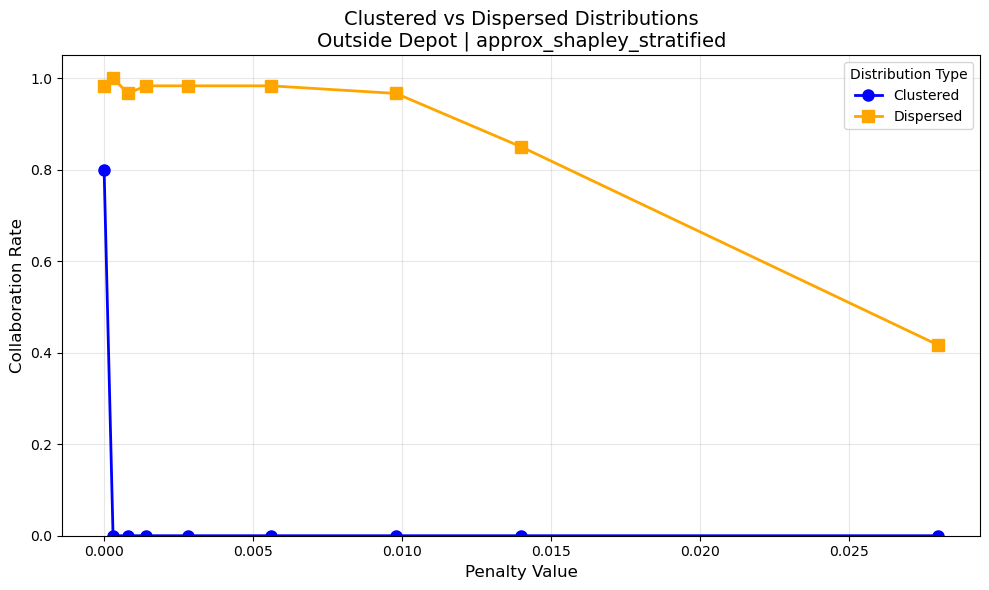

In [20]:
plot_clustered_vs_dispersed(leuven_summary_df, 
                            depot_location=
                            # 'inside', 
                            'outside',
                            method=
                             'approx_shapley_stratified',
                            # 'approx_shapley_mc',
                            # 'marginal',
                            # 'proportional'
                            )

In [21]:
# Compare inside vs outside depot locations
def plot_depot_comparison(summary_df, distribution='clustered', method='approx_shapley_mc', 
                          figsize=(12, 6)):
    """
    Compare collaboration rate between inside and outside depot locations.
    """
    subset = summary_df[(summary_df['distribution'] == distribution) & 
                        (summary_df['method'] == method)]
    
    fig, ax = plt.subplots(figsize=figsize)
    
    for depot_loc, color, marker in [('inside', 'blue', 'o'), ('outside', 'red', 's')]:
        data = subset[subset['depot_location'] == depot_loc].sort_values('penalty')
        if len(data) > 0:
            ax.plot(data['penalty'], data['collab_rate'], 
                    marker=marker, label=f'{depot_loc.title()} Depot', 
                    color=color, linewidth=2, markersize=8)
    
    ax.set_xlabel('Penalty Value', fontsize=12)
    ax.set_ylabel('Collaboration Rate', fontsize=12)
    ax.set_title(f'Collaboration Rate: Inside vs Outside Depot\n{distribution.title()} | {method}', 
                 fontsize=14)
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.05)
    
    plt.tight_layout()
    plt.show()



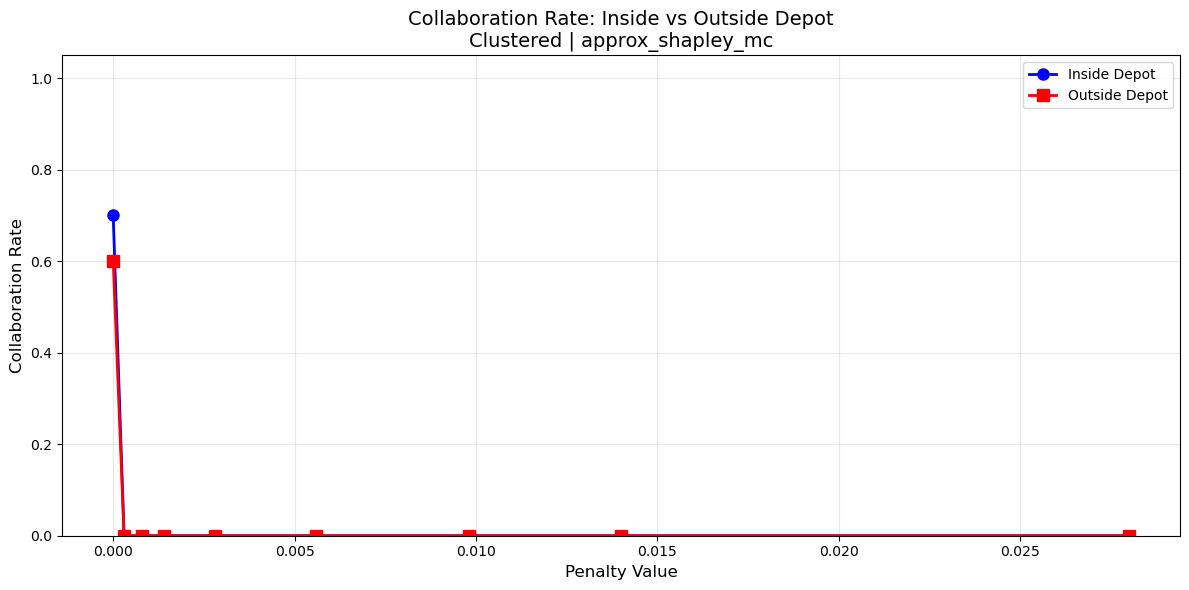

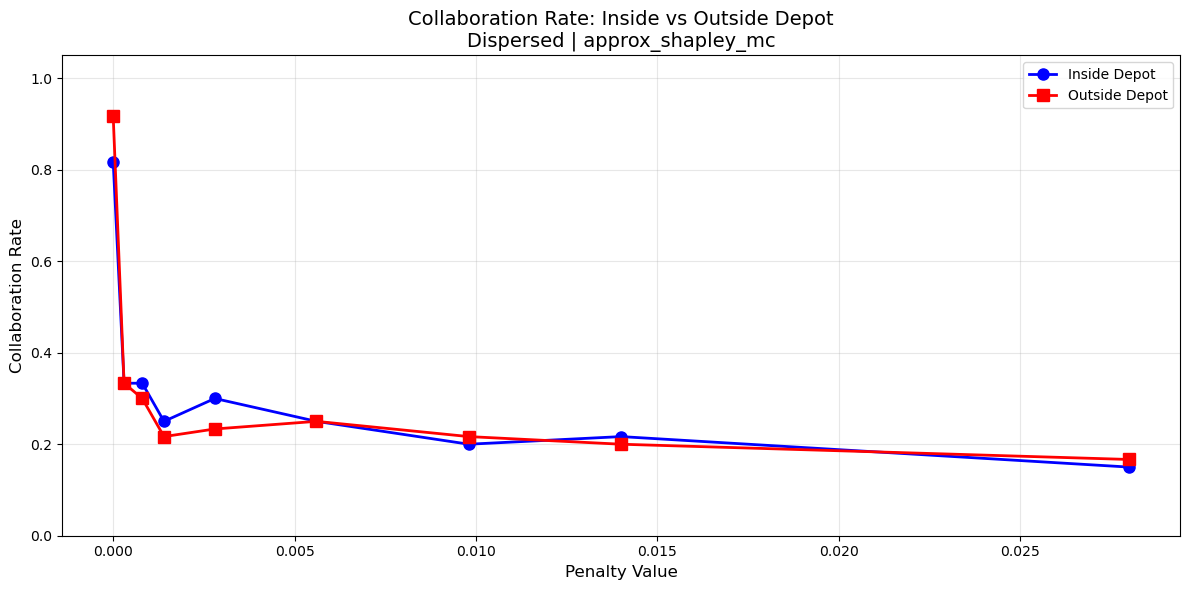

In [22]:
# Compare depot locations
plot_depot_comparison(leuven_summary_df, distribution='clustered', method='approx_shapley_mc')
plot_depot_comparison(leuven_summary_df, distribution='dispersed', method='approx_shapley_mc')

# Heatmap: Collaboration Rate by Depot Location and Distribution

In [23]:
# Create pivot table for heatmap
def create_collab_heatmap(summary_df, method='approx_shapley_mc', figsize=(10, 6)):
    """
    Create a heatmap showing collaboration rate across depot locations and distributions.
    """
    subset = summary_df[summary_df['method'] == method]
    
    # Create pivot table
    pivot = subset.pivot_table(
        values='collab_rate',
        index=['depot_location', 'distribution'],
        columns='penalty',
        aggfunc='mean'
    )
    
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax, 
                vmin=0, vmax=1, cbar_kws={'label': 'Collaboration Rate'})
    
    ax.set_title(f'Collaboration Rate Heatmap\nMethod: {method}', fontsize=14)
    ax.set_xlabel('Penalty Value')
    ax.set_ylabel('Depot Location / Distribution')
    
    plt.tight_layout()
    plt.show()


In [24]:
leuven_summary_df

,folder,depot_location,distribution,method,af,penalty,instance,total_receivers,collab_receivers,non_collab_receivers,collab_rate,mean_receiver_score,min_receiver_score,max_receiver_score,total_carriers,total_shipments,total_jsprit_cost,total_carrier_score,total_receiver_scores
0,leuvenCRCollab-outside-clustered-proportional-...,outside,clustered,proportional,0.8,0.0140,i01,NaN,0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,leuvenCRCollab-inside-clustered-approx_shapley...,inside,clustered,approx_shapley_stratified,0.8,0.0140,i01,NaN,0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,leuvenCRCollab-inside-clustered-marginal-af0.8...,inside,clustered,marginal,0.8,0.0003,i01,60.0,1,59.0,0.016667,-99.776767,-99.776767,-99.776767,4.0,60.0,-3561.998880,2763.897405,-5999.776767
3,leuvenCRCollab-inside-clustered-approx_shapley...,inside,clustered,approx_shapley_mc,0.8,0.0280,i01,NaN,0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,leuvenCRCollab-inside-clustered-approx_shapley...,inside,clustered,approx_shapley_stratified,0.8,0.0008,i01,NaN,0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,leuvenCRCollab-inside-clustered-approx_shapley...,inside,clustered,approx_shapley_mc,0.8,0.0098,i01,NaN,0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
140,leuvenCRCollab-outside-dispersed-approx_shaple...,outside,dispersed,approx_shapley_mc,0.8,0.0098,i01,60.0,13,47.0,0.216667,271.685709,51.976660,891.771328,4.0,60.0,-3736.354029,3703.857442,-2056.457254
141,leuvenCRCollab-outside-dispersed-marginal-af0....,outside,dispersed,marginal,0.8,0.0280,i01,60.0,7,53.0,0.116667,639.881129,-19.518087,907.475425,4.0,60.0,-3735.059419,3668.370334,-3668.498257
142,leuvenCRCollab-outside-clustered-approx_shaple...,outside,clustered,approx_shapley_stratified,0.8,0.0008,i01,NaN,0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


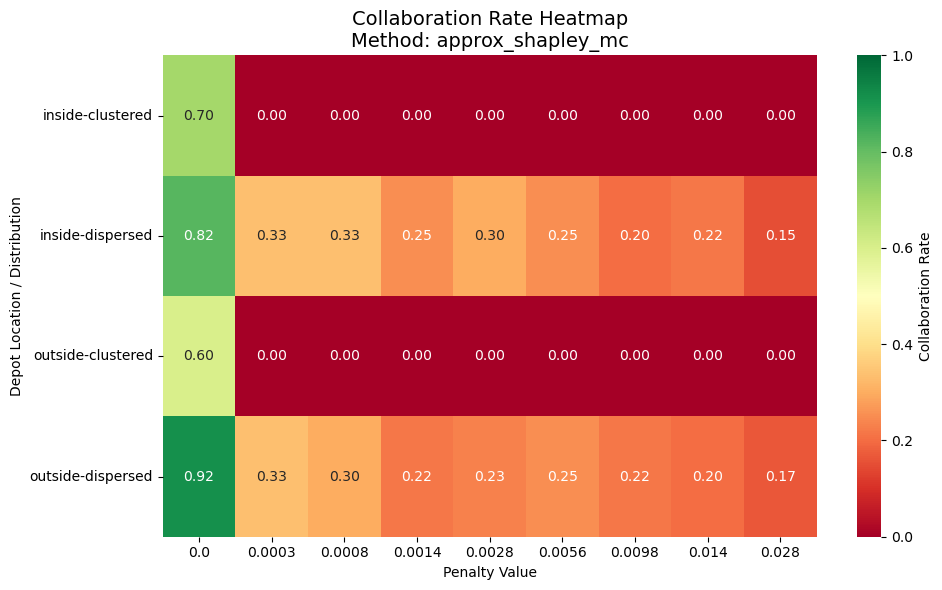

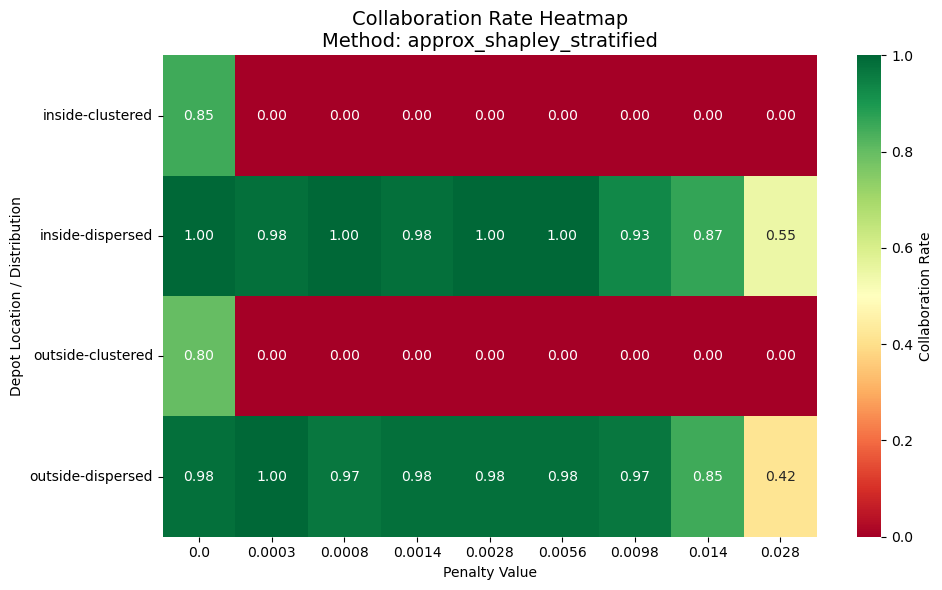

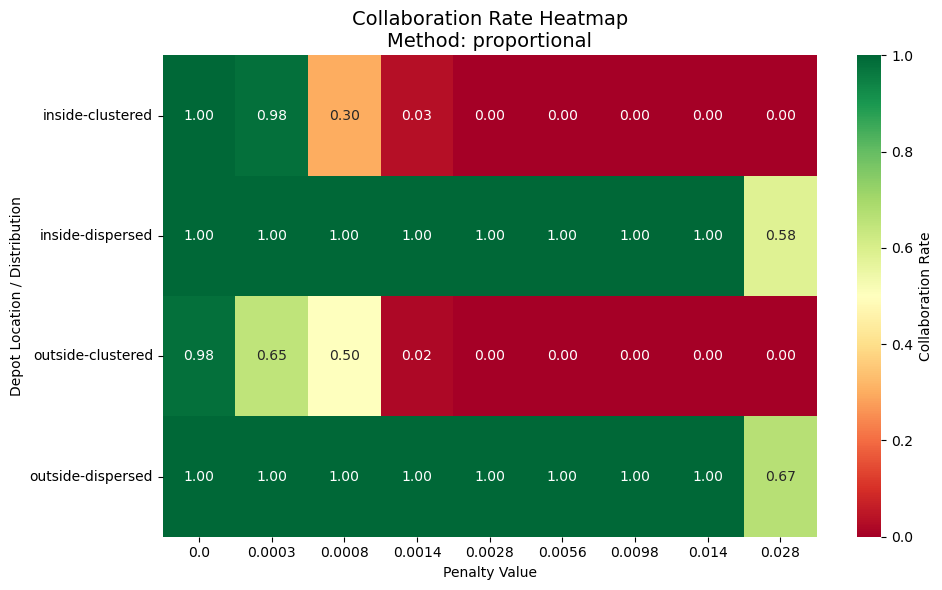

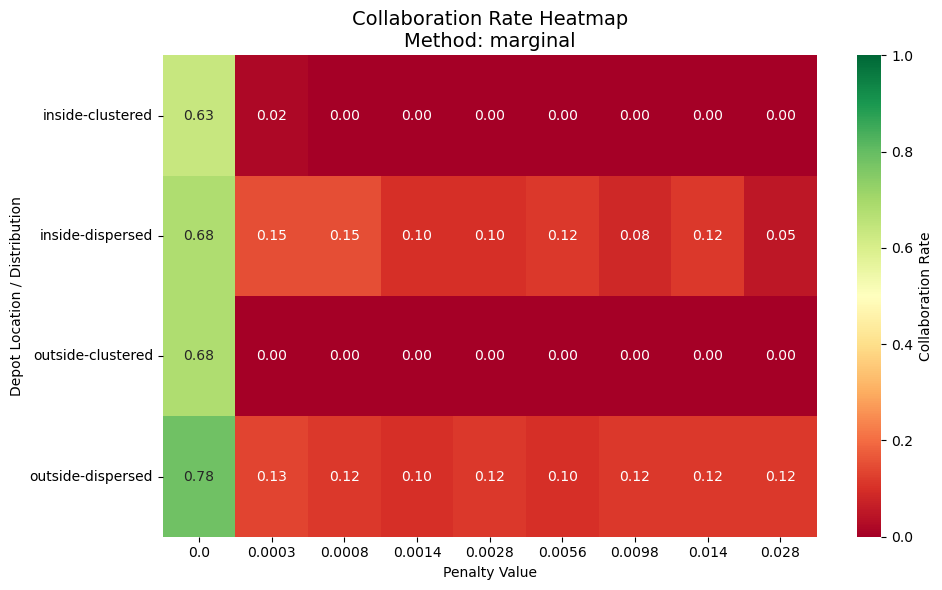

In [25]:

create_collab_heatmap(leuven_summary_df, method='approx_shapley_mc')
create_collab_heatmap(leuven_summary_df, method='approx_shapley_stratified')
create_collab_heatmap(leuven_summary_df, method='proportional')
create_collab_heatmap(leuven_summary_df, method='marginal')

# Receiver Score Analysis

/var/folders/wc/gp218rn503j731s25nggwptw0000gp/T/ipykernel_11430/2054583839.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([d for d in data_to_plot if len(d) > 0], labels=[l for l, d in zip(labels, data_to_plot) if len(d) > 0])


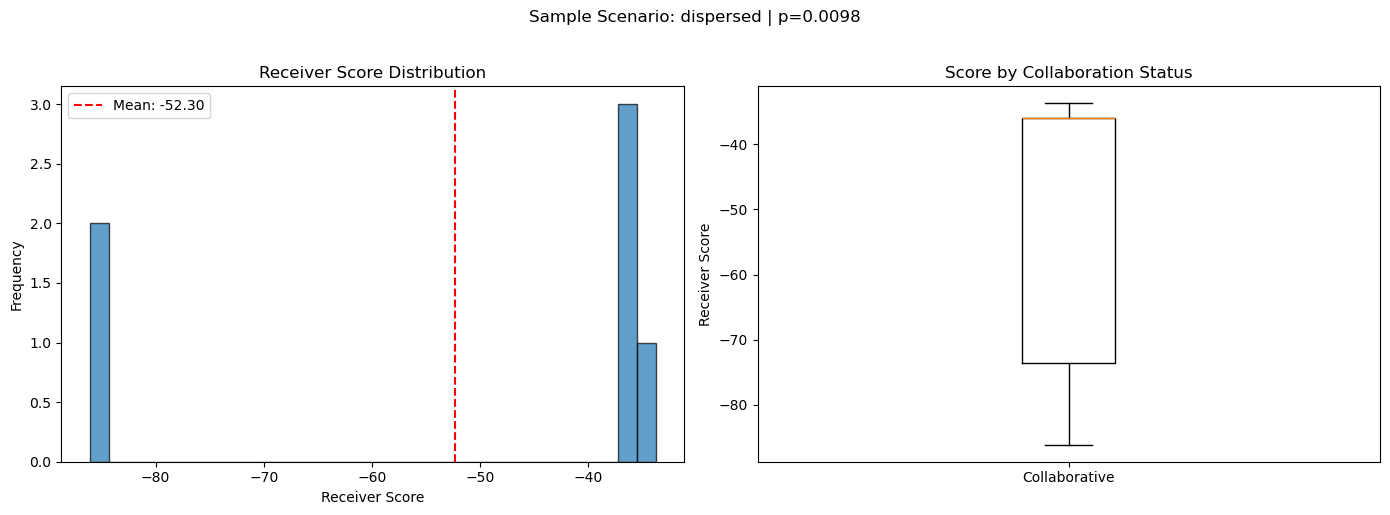

In [60]:
# Plot receiver scores distribution for a sample scenario
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution
valid_scores = sample_data['receiver_df'][sample_data['receiver_df']['score'] > -100]['score']
axes[0].hist(valid_scores, bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Receiver Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Receiver Score Distribution')
axes[0].axvline(valid_scores.mean(), color='red', linestyle='--', label=f'Mean: {valid_scores.mean():.2f}')
axes[0].legend()

# Score by collaboration status
receiver_df = sample_data['receiver_df']
collab_scores = receiver_df[receiver_df['collaboration_status'] == True]['score']
non_collab_scores = receiver_df[receiver_df['collaboration_status'] == False]['score']

data_to_plot = [collab_scores[collab_scores > -100], non_collab_scores[non_collab_scores > -100]]
labels = ['Collaborative', 'Non-Collaborative']
bp = axes[1].boxplot([d for d in data_to_plot if len(d) > 0], labels=[l for l, d in zip(labels, data_to_plot) if len(d) > 0])
axes[1].set_ylabel('Receiver Score')
axes[1].set_title('Score by Collaboration Status')

plt.suptitle(f"Sample Scenario: {sample_data['scenario_info']['distribution']} | p={sample_data['scenario_info']['penalty']}", 
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [107]:
leuven_summary_df

,folder,depot_location,distribution,method,af,penalty,instance,total_receivers,collab_receivers,non_collab_receivers,collab_rate,total_receiver_scores,mean_receiver_score,min_receiver_score,max_receiver_score,total_carriers,total_shipments,total_jsprit_cost,total_carrier_score
0,leuvenCRCollab-outside-clustered-proportional-...,outside,clustered,proportional,0.8,0.0140,i01,97.0,12,85.0,0.123711,-9464.022030,-78.536105,-96.954772,-23.280105,4.0,97.0,-2995.934413,7449.950470
1,leuvenCRCollab-inside-clustered-approx_shapley...,inside,clustered,approx_shapley_stratified,0.8,0.0140,i01,NaN,0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,leuvenCRCollab-inside-clustered-marginal-af0.8...,inside,clustered,marginal,0.8,0.0003,i01,97.0,1,96.0,0.010309,-9700.089763,NaN,NaN,NaN,4.0,97.0,-3252.328967,7028.367076
3,leuvenCRCollab-inside-clustered-approx_shapley...,inside,clustered,approx_shapley_mc,0.8,0.0280,i01,NaN,0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,leuvenCRCollab-inside-clustered-approx_shapley...,inside,clustered,approx_shapley_stratified,0.8,0.0008,i01,97.0,31,66.0,0.319588,-8261.875318,-40.631813,-85.274031,500.808664,4.0,97.0,-2801.420125,7702.766800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,leuvenCRCollab-inside-clustered-approx_shapley...,inside,clustered,approx_shapley_mc,0.8,0.0098,i01,NaN,0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
156,leuvenCRCollab-outside-dispersed-approx_shaple...,outside,dispersed,approx_shapley_mc,0.8,0.0098,i01,NaN,0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
157,leuvenCRCollab-outside-dispersed-marginal-af0....,outside,dispersed,marginal,0.8,0.0280,i01,NaN,0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
158,leuvenCRCollab-outside-clustered-approx_shaple...,outside,clustered,approx_shapley_stratified,0.8,0.0008,i01,97.0,29,68.0,0.298969,-9013.341625,-71.036065,-99.166667,10.458692,4.0,97.0,-2838.512961,7638.514183


In [118]:
# Receiver total score comparison across depot/distribution scenarios

def compare_receiver_avg_scores(summary_df, figsize=(20, 5)):
    """
    Plot receiver avg scores vs penalty for each allocation method,
    across four scenarios (inside/outside x clustered/dispersed) in one horizontal row.

    summary_df columns expected:
      - depot_location: 'inside' or 'outside'
      - distribution: 'clustered' or 'dispersed'
      - method: allocation method name
      - penalty: numeric penalty value
      - total_receivers: int
      - either 'total_receiver_score' OR 'mean_receiver_score' (used to back-calc total)
    """
    scenarios = [
        ('inside', 'clustered', 'Inside - Clustered'),
        ('inside', 'dispersed', 'Inside - Dispersed'),
        ('outside', 'clustered', 'Outside - Clustered'),
        ('outside', 'dispersed', 'Outside - Dispersed'),
    ]

    # Choose score column, fallback to mean * total
    has_total = 'total_receiver_scores' in summary_df.columns
    df = summary_df.copy()
    df['avg_receiver_score'] = df['total_receiver_scores'] / df['total_receivers']
    fig, axes = plt.subplots(1, 4, figsize=figsize, sharey=True)

    for ax, (depot_loc, dist, title) in zip(axes, scenarios):
        subset = df[(df['depot_location'] == depot_loc) &
                            (df['distribution'] == dist)]
        if subset.empty:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', fontsize=11)
            ax.set_title(title)
            ax.grid(True, alpha=0.3)
            continue

        methods = subset['method'].unique()
        for method in methods:
            method_df = subset[subset['method'] == method].sort_values('penalty')
            if method_df.empty:
                continue
            if has_total:
                y = method_df['avg_receiver_score']
            else:
                # derive total from mean * count when total is absent
                raise NotImplementedError("Total receiver score column is missing; back-calculation not implemented.")
            color = global_methodsAndColors.get(method, None)
            ax.plot(method_df['penalty'], y,
                    marker='o', linewidth=2, markersize=6,
                    label=method if depot_loc == 'inside' and dist == 'clustered' else None,
                    color=color)

        ax.set_title(title, fontsize=12)
        ax.set_xlabel('Penalty')
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel('Receiver Total Score')

    # Global legend (from first axes handles)
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, title='Method', loc='upper center', ncol=len(handles), fontsize=9)
    fig.suptitle('Receiver Total Scores across Scenarios', fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

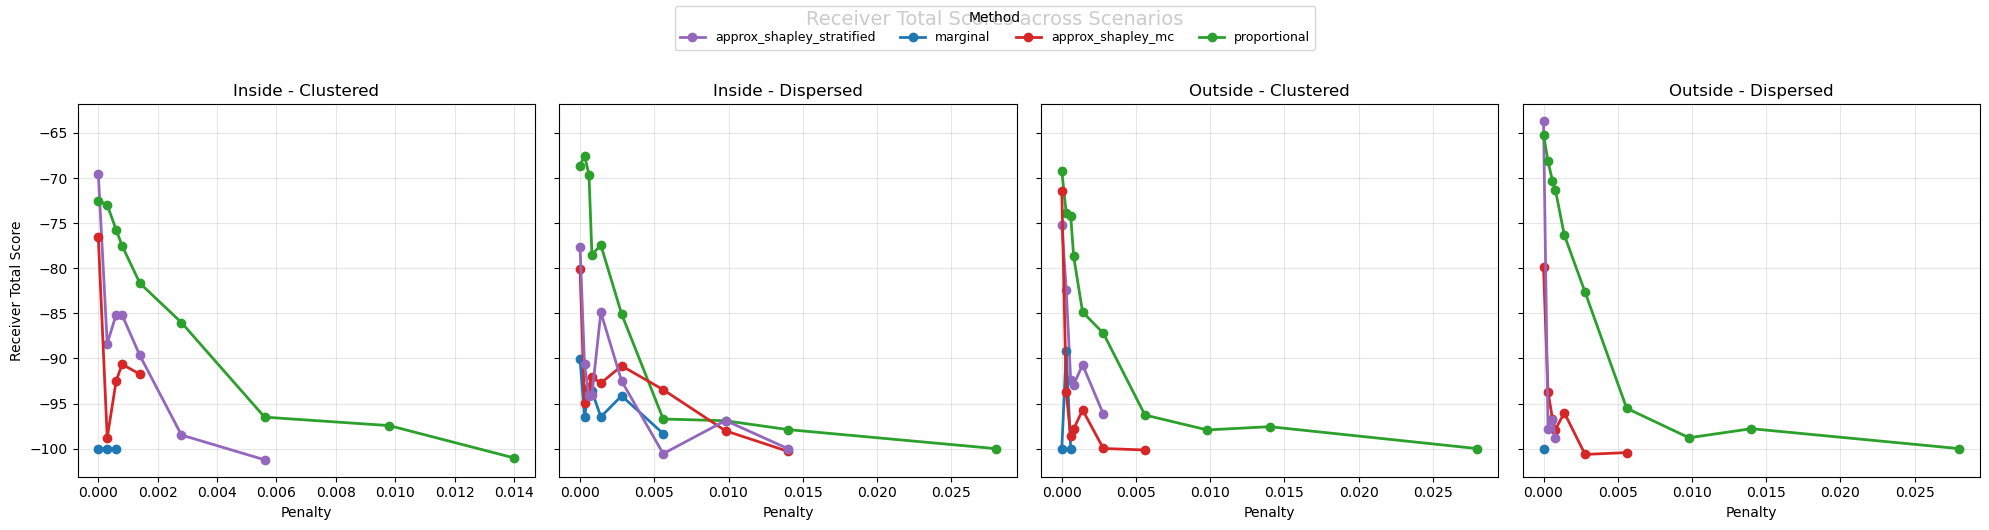

In [119]:
compare_receiver_avg_scores(leuven_summary_df)

# Carrier Analysis

In [120]:
# Display carrier information
carrier_df = sample_data['carrier_df']
print(f"Number of carriers: {len(carrier_df)}")
print(f"Total shipments: {carrier_df['num_shipments'].sum()}")
print(f"Total jsprit cost: {carrier_df['jsprit_score'].sum():.2f}")
carrier_df

Number of carriers: 4
Total shipments: 92
Total jsprit cost: -2378.06


,carrier_id,depot_link_ids,depot_link_id,vehicle_ids,num_vehicles,jsprit_score,carrier_score,num_shipments
0,carrier_333784188_r_3,[333784188_r_3],333784188_r_3,"[lightVan_carrier_333784188_r_3, heavyVan_carr...",2,-563.569284,1609.491992,20
1,carrier_27566523_11,[27566523_11],27566523_11,"[lightVan_carrier_27566523_11, heavyVan_carrie...",2,-592.838574,1895.959722,23
2,carrier_25806807_r_1,[25806807_r_1],25806807_r_1,"[lightVan_carrier_25806807_r_1, heavyVan_carri...",2,-603.932668,2055.338149,24
3,carrier_131757263_1-131757263_2,[131757263_1-131757263_2],131757263_1-131757263_2,"[lightVan_carrier_131757263_1-131757263_2, hea...",2,-617.718341,2277.079332,25


In [121]:
# Analyze collaboration by affiliated carrier
collab_by_carrier = count_collaborative_receivers_by_carrier(sample_data['receiver_df'])
collab_by_carrier['collab_rate'] = collab_by_carrier['collab_receivers'] / collab_by_carrier['total_receivers']
collab_by_carrier

,affiliated_carrier_id,total_receivers,collab_receivers,mean_score,collab_rate
0,0,20,20,-77.666090,1.0
1,1,23,23,-74.238921,1.0
2,2,24,24,-79.244354,1.0
3,3,25,25,-55.113512,1.0


# Carrier Cost Analysis Across Scenarios

In [125]:
leuven_summary_df

,folder,depot_location,distribution,method,af,penalty,instance,total_receivers,collab_receivers,non_collab_receivers,collab_rate,total_receiver_scores,mean_receiver_score,min_receiver_score,max_receiver_score,total_carriers,total_shipments,total_jsprit_cost,total_carrier_score
0,leuvenCRCollab-outside-clustered-proportional-...,outside,clustered,proportional,0.8,0.0140,i01,97.0,12,85.0,0.123711,-9464.022030,-78.536105,-96.954772,-23.280105,4.0,97.0,-2995.934413,7449.950470
1,leuvenCRCollab-inside-clustered-approx_shapley...,inside,clustered,approx_shapley_stratified,0.8,0.0140,i01,NaN,0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,leuvenCRCollab-inside-clustered-marginal-af0.8...,inside,clustered,marginal,0.8,0.0003,i01,97.0,1,96.0,0.010309,-9700.089763,NaN,NaN,NaN,4.0,97.0,-3252.328967,7028.367076
3,leuvenCRCollab-inside-clustered-approx_shapley...,inside,clustered,approx_shapley_mc,0.8,0.0280,i01,NaN,0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,leuvenCRCollab-inside-clustered-approx_shapley...,inside,clustered,approx_shapley_stratified,0.8,0.0008,i01,97.0,31,66.0,0.319588,-8261.875318,-40.631813,-85.274031,500.808664,4.0,97.0,-2801.420125,7702.766800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,leuvenCRCollab-inside-clustered-approx_shapley...,inside,clustered,approx_shapley_mc,0.8,0.0098,i01,NaN,0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
156,leuvenCRCollab-outside-dispersed-approx_shaple...,outside,dispersed,approx_shapley_mc,0.8,0.0098,i01,NaN,0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
157,leuvenCRCollab-outside-dispersed-marginal-af0....,outside,dispersed,marginal,0.8,0.0280,i01,NaN,0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
158,leuvenCRCollab-outside-clustered-approx_shaple...,outside,clustered,approx_shapley_stratified,0.8,0.0008,i01,97.0,29,68.0,0.298969,-9013.341625,-71.036065,-99.166667,10.458692,4.0,97.0,-2838.512961,7638.514183


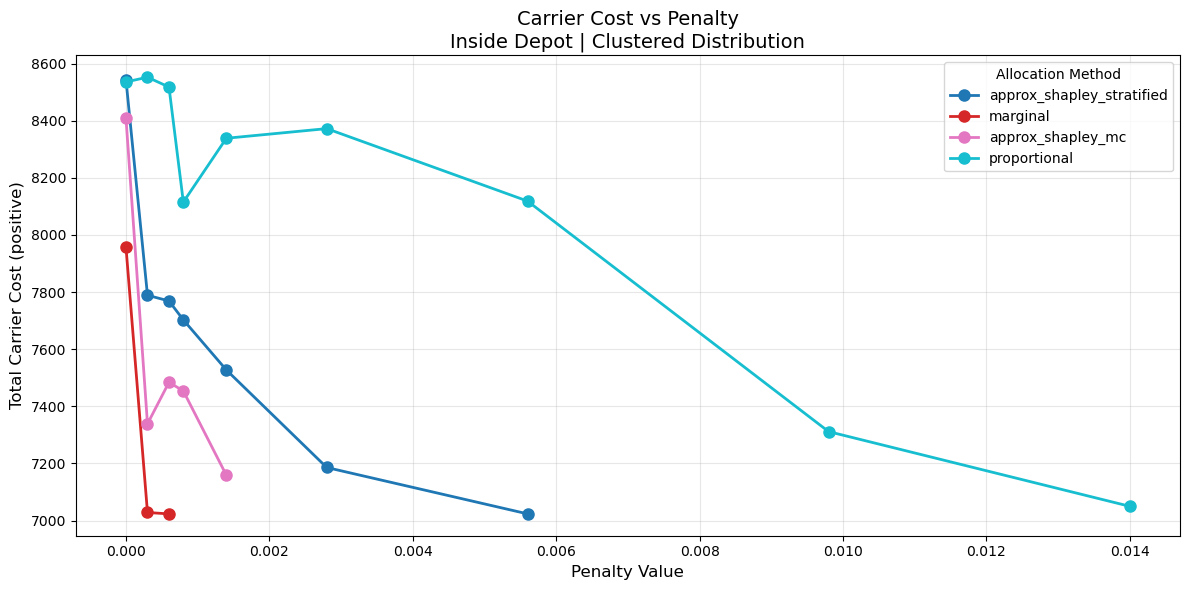

In [124]:
# Plot total jsprit cost vs penalty
def plot_carrier_cost_vs_penalty(summary_df, depot_location='inside', distribution='clustered', 
                                  figsize=(12, 6)):
    """
    Plot total jsprit cost vs penalty for different allocation methods.
    """
    subset = summary_df[(summary_df['depot_location'] == depot_location) & 
                        (summary_df['distribution'] == distribution)]
    
    fig, ax = plt.subplots(figsize=figsize)
    
    methods = subset['method'].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))
    
    for method, color in zip(methods, colors):
        method_data = subset[subset['method'] == method].sort_values('penalty')
        ax.plot(method_data['penalty'], method_data['total_carrier_score'],  # Negate to show as positive cost
                marker='o', label=method, color=color, linewidth=2, markersize=8)
    
    ax.set_xlabel('Penalty Value', fontsize=12)
    ax.set_ylabel('Total Carrier Cost (positive)', fontsize=12)
    ax.set_title(f'Carrier Cost vs Penalty\n{depot_location.title()} Depot | {distribution.title()} Distribution', 
                 fontsize=14)
    ax.legend(title='Allocation Method', loc='best')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_carrier_cost_vs_penalty(leuven_summary_df, depot_location='inside', distribution='clustered')

# Save Summary Data to CSV

In [ ]:
# Save the summary dataframe for later use
leuven_summary_df.to_csv('output/leuven_scenario_summary.csv', index=False)
print(f"Saved summary to output/leuven_scenario_summary.csv")
leuven_summary_df